# Autocorrelation & the Autocorrelation Function (ACF)

- The **autocorrelation** of a series tells us **how the values in the series influence each other over time** — i.e. how correlated a value is with its own past.
- The **Autocorrelation Function (ACF)** is just the autocorrelation computed at **many different lags** $k = 0, 1, 2, \dots$

It answers: *"if today is high, does that tell me anything about yesterday / last week / last month?"*

## 1. The formula

Autocorrelation at lag $k$:

$$\rho_k = \frac{\text{Autocovariance at lag } k}{\text{Variance of series}} = \frac{\sum_{t=k+1}^{T} (y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T} (y_t - \bar{y})^2}$$

where $\bar{y}$ is the **mean** of the whole series and $T$ is its length.

**Reading the result:**

| Value of $\rho_k$ | Meaning |
|---|---|
| $\rho_k \approx +1$ | strong **positive** relationship with the value $k$ steps ago |
| $\rho_k \approx -1$ | strong **negative** relationship |
| $\rho_k \approx 0$ | **no** relationship at that lag |

A couple of facts that fall straight out of the formula:
- **$\rho_0 = 1$ always** — a series is perfectly correlated with itself (numerator = denominator).
- The denominator (the variance term) is the **same for every lag**; only the numerator changes.

## 2. The key idea: shift the series against itself

To get lag $k$, line the series up against a **copy of itself shifted by $k$ steps**, then correlate the overlapping part. In the slides this is the $y_0, y_1, y_2$ rows:

| | t=1 | t=2 | t=3 | t=4 | t=5 | … |
|---|---|---|---|---|---|---|
| $y_0$ (original) | 25 | 7 | 19 | 31 | 41 | … |
| $y_1$ (lag 1) | – | 25 | 7 | 19 | 31 | … |
| $y_2$ (lag 2) | – | – | 25 | 7 | 19 | … |

- $y_1$ is the series pushed **one step forward** — so column $t$ pairs $y_t$ with $y_{t-1}$.
- $y_2$ is pushed **two steps** — pairing $y_t$ with $y_{t-2}$.

The autocovariance at lag $k$ multiplies the **(deviation-from-mean)** of each overlapping pair and sums them.

## 3. A full worked example ($T = 20$)

Here is a **complete** 20-value series (same flavour as the lecture's, but with every value shown so we can reproduce every number):

| $t$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 15 | 16 | 17 | 18 | 19 | 20 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| $y_t$ | 25 | 7 | 19 | 31 | 41 | 18 | 35 | 42 | 20 | 28 | 33 | 45 | 18 | 30 | 25 | 32 | 40 | 15 | 46 | 50 |

### Step 1 — mean and variance
$$\bar{y} = \frac{25+7+19+\dots+46+50}{20} = \frac{600}{20} = \mathbf{30}$$
$$\sum_{t=1}^{20}(y_t-\bar{y})^2 = (25-30)^2 + (7-30)^2 + \dots + (50-30)^2 = 2602$$
$$\text{Var} = \frac{2602}{20} = \mathbf{130.1} \quad(\text{this is the autocovariance at lag } 0)$$

### Step 2 — autocovariance at lag 0
The numerator equals the variance numerator, so:
$$\text{autocov}(0) = \frac{2602}{20} = 130.1 \qquad \rho_0 = \frac{130.1}{130.1} = \mathbf{1}$$

### Step 3 — autocovariance at lag 1
Pair each $y_t$ with $y_{t-1}$ (the $y_0$ vs $y_1$ overlap), in deviations from the mean:
$$\sum_{t=2}^{20}(y_t-30)(y_{t-1}-30) = \underbrace{(7-30)(25-30)}_{115} + \underbrace{(19-30)(7-30)}_{253} + \dots + \underbrace{(50-30)(46-30)}_{320} = -65$$
$$\text{autocov}(1) = \frac{-65}{20} = -3.25 \qquad \rho_1 = \frac{-3.25}{130.1} = \mathbf{-0.025}$$

### Step 4 — autocovariance at lag 2
Pair each $y_t$ with $y_{t-2}$:
$$\sum_{t=3}^{20}(y_t-30)(y_{t-2}-30) = \underbrace{(19-30)(25-30)}_{55} + \underbrace{(31-30)(7-30)}_{-23} + \dots + \underbrace{(50-30)(15-30)}_{-300} = -520$$
$$\text{autocov}(2) = \frac{-520}{20} = -26.0 \qquad \rho_2 = \frac{-26.0}{130.1} = \mathbf{-0.1998}$$

### Result

| Lag $k$ | Autocovariance | Autocorrelation $\rho_k$ | Reading |
|---|---|---|---|
| 0 | 130.1 | $1.000$ | (always 1) |
| 1 | $-3.25$ | $-0.025$ | essentially **no** relationship 1 step apart |
| 2 | $-26.0$ | $-0.200$ | **mild negative** relationship 2 steps apart |

> **Note on the denominator.** We divide the autocovariance by $T = 20$ (not $T-k$). This is the **biased** estimator — exactly what `statsmodels` and `numpy` use by default, so the code below will reproduce these numbers. (Since the *same* $T$ divides both the numerator and the denominator of $\rho_k$, it cancels — which is why $\rho_k$ is just the ratio of the two sums.)

## 4. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)

# the full 20-value series from section 3 -> every number below is reproducible
y = np.array([25, 7, 19, 31, 41, 18, 35, 42, 20, 28,
              33, 45, 18, 30, 25, 32, 40, 15, 46, 50], dtype=float)
T = len(y)
ybar = y.mean()
print("series :", y)
print("T =", T, "  mean =", round(ybar, 3), "  var(biased) =", round(y.var(), 3))

series : [25.  7. 19. 31. 41. 18. 35. 42. 20. 28. 33. 45. 18. 30. 25. 32. 40. 15.
 46. 50.]
T = 20   mean = 30.0   var(biased) = 130.1


## 5. The lag-shifted view

In [2]:
shift = pd.DataFrame({
    "y0 (original)": y,
    "y1 (lag 1)":    pd.Series(y).shift(1),
    "y2 (lag 2)":    pd.Series(y).shift(2),
}, index=range(1, T + 1))
shift

,y0 (original),y1 (lag 1),y2 (lag 2)
1,25.0,25.0,NaN
2,7.0,7.0,25.0
3,19.0,19.0,7.0
4,31.0,31.0,19.0
5,41.0,41.0,31.0
6,18.0,18.0,41.0
7,35.0,35.0,18.0
8,42.0,42.0,35.0
9,20.0,20.0,42.0
10,28.0,28.0,20.0


## 6. ACF by hand, straight from the formula

In [3]:
def autocovariance(y, k):
    ybar = y.mean()
    # sum over the overlapping pairs (y_t , y_{t-k})
    return np.sum((y[k:] - ybar) * (y[:T - k] - ybar)) / len(y)   # divide by T (biased)

def autocorrelation(y, k):
    return autocovariance(y, k) / autocovariance(y, 0)            # var = autocov at lag 0

acf_table = pd.DataFrame({
    "lag k":          range(0, 6),
    "autocovariance": [autocovariance(y, k) for k in range(6)],
    "rho_k (ACF)":    [autocorrelation(y, k) for k in range(6)],
}).round(4)
acf_table

,lag k,autocovariance,rho_k (ACF)
0,0,130.10,1.0000
1,1,-3.25,-0.0250
2,2,-26.00,-0.1998
3,3,11.95,0.0919
4,4,13.10,0.1007
5,5,-3.90,-0.0300


This reproduces the hand calculation from section 3: `rho_k` at lag 0 is exactly **1**, lag 1 ≈ **−0.025**, lag 2 ≈ **−0.200**, and the lag-0 `autocovariance` equals the (biased) **variance** (130.1).

## 7. Cross-check with statsmodels / numpy

In [4]:
from statsmodels.tsa.stattools import acf

sm_acf = acf(y, nlags=5, fft=False)        # biased estimator by default -> matches ours
print("statsmodels ACF:", np.round(sm_acf, 4))
print("our ACF        :", np.round([autocorrelation(y, k) for k in range(6)], 4))

statsmodels ACF: [ 1.     -0.025  -0.1998  0.0919  0.1007 -0.03  ]
our ACF        : [ 1.     -0.025  -0.1998  0.0919  0.1007 -0.03  ]


## 8. The ACF plot (correlogram)

The standard way to view the ACF is a **stem plot** of $\rho_k$ vs lag $k$. The shaded band is the 95% confidence interval ($\approx \pm 1.96/\sqrt{T}$); spikes **outside** the band are statistically significant.

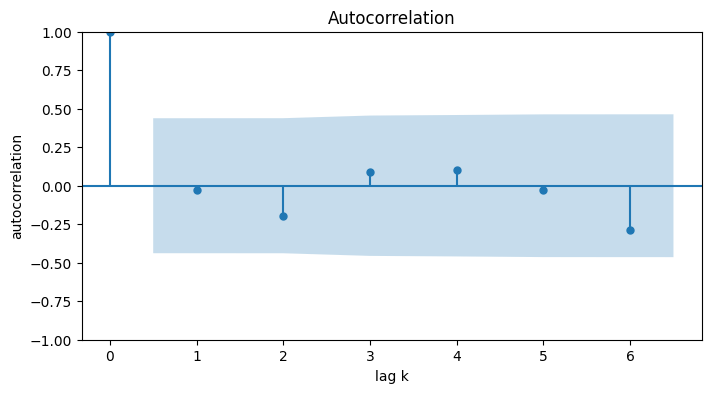

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots()
plot_acf(y, lags=6, ax=ax)
plt.xlabel("lag k"); plt.ylabel("autocorrelation")
plt.show()

## 9. Why the ACF matters

- **Detecting seasonality:** a repeating spike every $m$ lags (e.g. lag 12 on monthly data) signals a seasonal cycle of period $m$.
- **Detecting trend / non-stationarity:** an ACF that decays *very slowly* over many lags means the series is non-stationary (often needs differencing).
- **Choosing model orders:** the ACF (with its partner the **PACF**) is the main tool for picking the MA / AR orders of an **ARIMA** model.
- **Checking residuals:** after fitting a model, a *good* model leaves residuals whose ACF is ≈ 0 at all non-zero lags (white noise).

## 10. Summary

- $\rho_k$ measures how a value relates to the value **$k$ steps earlier**; the **ACF** is $\rho_k$ across all lags.
- Computed by **shifting the series against itself** and correlating the overlap.
- $\rho_0 = 1$ always; $\rho_k$ near $\pm1$ = strong relationship, near $0$ = none.
- The common (biased) estimator divides by $T$ — matching `statsmodels`/`numpy`.
- Read it off the **correlogram**; it's the gateway to ARIMA modelling.